# WCS 02 — Astrometry Correspondence Residuals

**What this notebook tests:**
- For each astrometry-confirmed star, compare the WCS-predicted sky position with the catalog position from the corr file.
- Are residuals small and random (noise-limited), or large and coherent (unmodelled distortion)?
- Do residuals worsen toward the image edges?

**Method:** The corr file contains `field_x/y` (our pixel position) and `index_ra/dec` (catalog RA/Dec). We convert `field_x/y` through the solved WCS to get `field_ra/dec` and compare with `index_ra/dec`.

In [3]:
import sys
from pathlib import Path
import warnings
import pickle
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

OUT_DIR = ROOT / 'out' / 'wcs_diagnostics'
CACHE   = OUT_DIR / 'platesolve_result.pkl'

if not CACHE.exists():
    raise FileNotFoundError(f'Run wcs_01 first to create {CACHE}')
with open(CACHE, 'rb') as f:
    result = pickle.load(f)

with afits.open(sorted((ROOT / 'data').glob('*.fit'))[0]) as hdul:
    image = hdul[0].data.astype(float)
h, w = image.shape

print(f'Loaded: {len(result.detected_x)} detected, {len(result.matched_x)} matched')
ctbl = getattr(result, 'corr_table', None)
if ctbl is not None:
    print(f'corr_table: {len(ctbl)} rows')
    print(f'  columns: {ctbl.colnames}')
else:
    fs = getattr(result, 'fetch_status', {})
    print(f'corr_table: NOT available  (fetch_status corr={fs.get("corr", "not recorded")})')
    print('  Delete the cache file and re-run wcs_01 with the updated platesolve.py.')


Loaded: 255 detected, 48 matched
corr_table: 48 rows
  columns: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']


In [4]:
if ctbl is None:
    raise RuntimeError('No corr_table available — see setup cell above.')

def _col(tbl, *names):
    for n in names:
        if n in tbl.colnames:
            return n
    return None

# Pixel positions of submitted sources
fld_x_col  = _col(ctbl, 'field_x',   'FIELD_X')
fld_y_col  = _col(ctbl, 'field_y',   'FIELD_Y')
# Pixel positions of reference catalog stars (index frame)
idx_x_col  = _col(ctbl, 'index_x',   'INDEX_X')
idx_y_col  = _col(ctbl, 'index_y',   'INDEX_Y')
# Sky positions: WCS-predicted for field sources
fld_ra_col  = _col(ctbl, 'field_ra',  'FIELD_RA')
fld_dec_col = _col(ctbl, 'field_dec', 'FIELD_DEC')
# Sky positions: catalog reference
idx_ra_col  = _col(ctbl, 'index_ra',  'INDEX_RA')
idx_dec_col = _col(ctbl, 'index_dec', 'INDEX_DEC')

print('Column availability:')
print(f'  field_x/y   (submitted px)   : {fld_x_col}, {fld_y_col}')
print(f'  index_x/y   (catalog px)     : {idx_x_col}, {idx_y_col}')
print(f'  field_ra/dec (submitted sky) : {fld_ra_col}, {fld_dec_col}')
print(f'  index_ra/dec (catalog sky)   : {idx_ra_col}, {idx_dec_col}')

has_px_residuals  = (fld_x_col and idx_x_col and fld_y_col and idx_y_col)
has_sky_residuals = (idx_ra_col and idx_dec_col and fld_x_col and fld_y_col)

print()
print(f'Pixel residuals available  : {has_px_residuals}')
print(f'Sky residuals available    : {has_sky_residuals}')
print(f'  ({len(ctbl)} correspondence rows)')


Column availability:
  field_x/y   (submitted px)   : field_x, field_y
  index_x/y   (catalog px)     : index_x, index_y
  field_ra/dec (submitted sky) : field_ra, field_dec
  index_ra/dec (catalog sky)   : index_ra, index_dec

Pixel residuals available  : index_y
Sky residuals available    : field_y
  (48 correspondence rows)


In [5]:
fx = np.asarray(ctbl[fld_x_col], dtype=float)
fy = np.asarray(ctbl[fld_y_col], dtype=float)
cx, cy = w / 2.0, h / 2.0
radius_px = np.hypot(fx - cx, fy - cy)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

# Approximate plate scale for px↔arcsec conversion
cd11 = result.header.get('CD1_1', 0); cd21 = result.header.get('CD2_1', 0)
cd12 = result.header.get('CD1_2', 0); cd22 = result.header.get('CD2_2', 0)
scale_as = (np.hypot(cd11, cd21) + np.hypot(cd12, cd22)) / 2 * 3600  # arcsec/px

# --- Pixel residuals (primary metric) ---
resid_px = dx_px = dy_px = None
if has_px_residuals:
    ix = np.asarray(ctbl[idx_x_col], dtype=float)
    iy = np.asarray(ctbl[idx_y_col], dtype=float)
    dx_px    = fx - ix
    dy_px    = fy - iy
    resid_px = np.hypot(dx_px, dy_px)

# --- Sky residuals (secondary metric, requires WCS-predicting field positions) ---
sep_arcsec = dra_as = ddec_as = None
if has_sky_residuals:
    cat_ra  = np.asarray(ctbl[idx_ra_col],  dtype=float)
    cat_dec = np.asarray(ctbl[idx_dec_col], dtype=float)
    wcs_ra, wcs_dec = wcs.pixel_to_world_values(fx, fy)
    wcs_sky = SkyCoord(ra=wcs_ra * u.deg, dec=wcs_dec * u.deg)
    cat_sky = SkyCoord(ra=cat_ra * u.deg, dec=cat_dec * u.deg)
    sep_arcsec = wcs_sky.separation(cat_sky).arcsec
    cos_dec = np.cos(np.radians(cat_dec))
    dra_as  = (wcs_ra  - cat_ra)  * cos_dec * 3600
    ddec_as = (wcs_dec - cat_dec) * 3600

print(f'Plate scale : {scale_as:.2f}" / px')
print()

if resid_px is not None:
    print('=== Pixel residuals (field_x/y − index_x/y) ===')
    print(f'  N              : {len(resid_px)}')
    print(f'  Median         : {np.median(resid_px):.3f} px  ({np.median(resid_px)*scale_as:.1f}")')
    print(f'  RMS            : {np.sqrt(np.mean(resid_px**2)):.3f} px  ({np.sqrt(np.mean(resid_px**2))*scale_as:.1f}")')
    print(f'  68th pct       : {np.percentile(resid_px, 68):.3f} px')
    print(f'  95th pct       : {np.percentile(resid_px, 95):.3f} px')
    print(f'  Max            : {resid_px.max():.3f} px')

if sep_arcsec is not None:
    print()
    print('=== Angular residuals (WCS-predicted vs catalog) ===')
    print(f'  N              : {len(sep_arcsec)}')
    print(f'  Median         : {np.median(sep_arcsec):.2f}"  ({np.median(sep_arcsec)/scale_as:.3f} px)')
    print(f'  RMS            : {np.sqrt(np.mean(sep_arcsec**2)):.2f}"')
    print(f'  95th pct       : {np.percentile(sep_arcsec, 95):.2f}"')
    print(f'  Max            : {sep_arcsec.max():.2f}"')


Plate scale : 81.02" / px

=== Pixel residuals (field_x/y − index_x/y) ===
  N              : 48
  Median         : 1.557 px  (126.1")
  RMS            : 3.250 px  (263.3")
  68th pct       : 2.180 px
  95th pct       : 8.074 px
  Max            : 9.312 px

=== Angular residuals (WCS-predicted vs catalog) ===
  N              : 48
  Median         : 154.46"  (1.906 px)
  RMS            : 259.51"
  95th pct       : 567.56"
  Max            : 745.66"


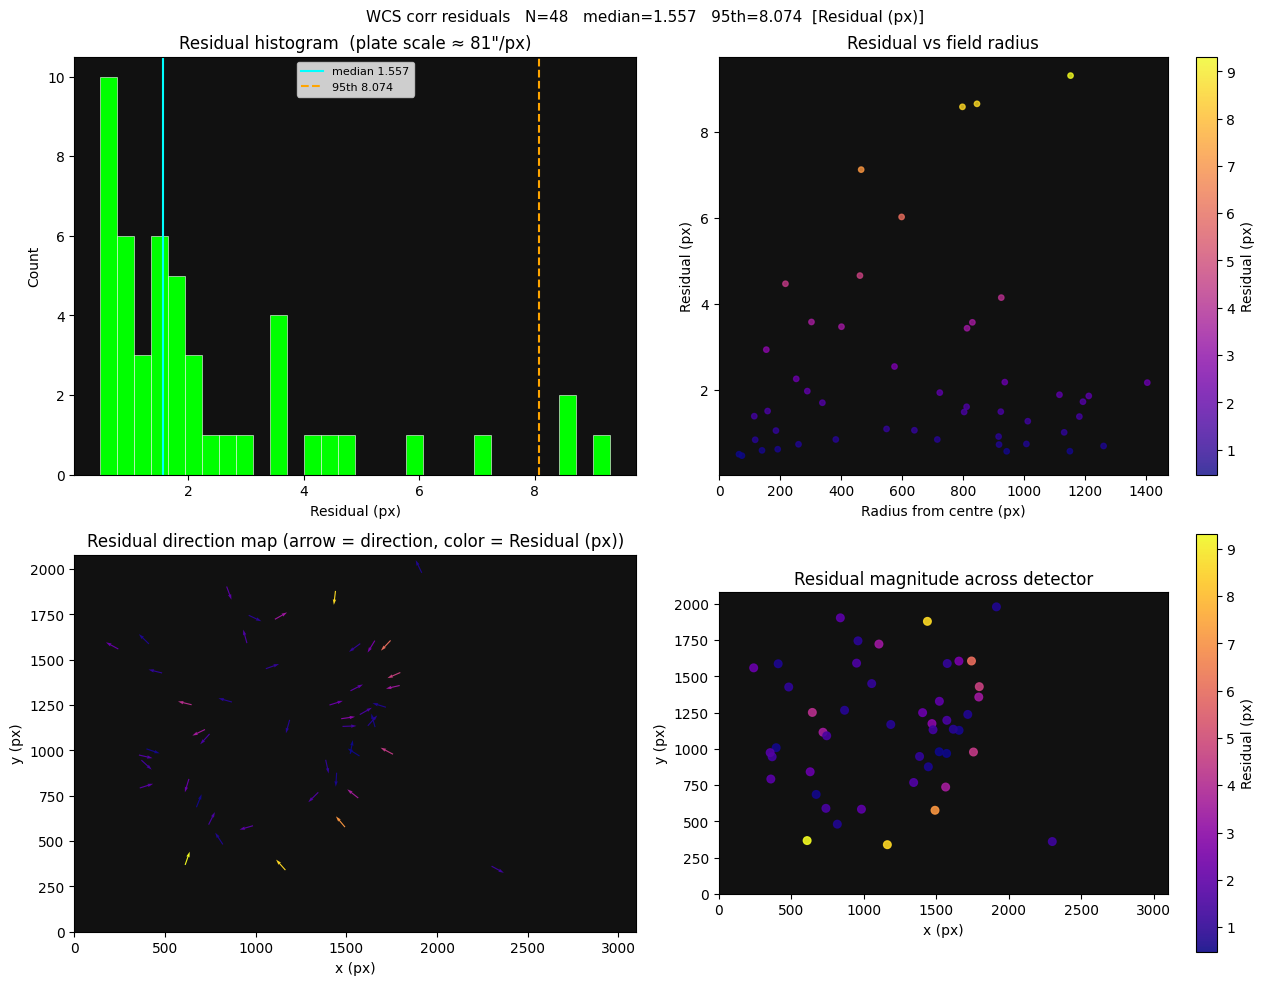

Saved wcs02_residuals.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Choose primary residual metric: prefer pixels if available, fall back to arcsec
if resid_px is not None:
    primary  = resid_px
    p_label  = 'Residual (px)'
    p_med    = np.median(resid_px)
    p_95     = np.percentile(resid_px, 95)
    vec_x, vec_y = dx_px, dy_px
elif sep_arcsec is not None:
    primary  = sep_arcsec
    p_label  = 'Residual (arcsec)'
    p_med    = np.median(sep_arcsec)
    p_95     = np.percentile(sep_arcsec, 95)
    vec_x, vec_y = dra_as, ddec_as
else:
    raise RuntimeError('No residual data available — check corr_table columns.')

# 1. Residual histogram
ax = axes[0, 0]
ax.set_facecolor('#111')
ax.hist(primary, bins=30, color='lime', edgecolor='white', linewidth=0.4)
ax.axvline(p_med, color='cyan',   lw=1.5, label=f'median {p_med:.3f}')
ax.axvline(p_95,  color='orange', lw=1.5, linestyle='--', label=f'95th {p_95:.3f}')
ax.set_xlabel(p_label); ax.set_ylabel('Count')
ax.set_title(f'Residual histogram  (plate scale ≈ {scale_as:.0f}"/px)')
ax.legend(fontsize=8)

# 2. Residual vs radius
ax = axes[0, 1]
ax.set_facecolor('#111')
sc = ax.scatter(radius_px, primary, c=primary, cmap='plasma', s=15, alpha=0.8)
plt.colorbar(sc, ax=ax, label=p_label)
ax.set_xlabel('Radius from centre (px)'); ax.set_ylabel(p_label)
ax.set_title('Residual vs field radius')

# 3. Residual direction map
# Arrows are normalised to unit length so they show direction only; colour shows magnitude.
ax = axes[1, 0]
ax.set_facecolor('#111')
ax.set_aspect('equal')
mag = np.hypot(vec_x, vec_y)
mag_safe = np.where(mag < 1e-12, 1.0, mag)
ux, uy = vec_x / mag_safe, vec_y / mag_safe
ax.quiver(fx, fy, ux, uy, primary, cmap='plasma',
          scale=40, scale_units='width', width=0.002)
ax.set_xlim(0, w); ax.set_ylim(0, h)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title(f'Residual direction map (arrow = direction, color = {p_label})')

# 4. Residual magnitude over detector
ax = axes[1, 1]
ax.set_facecolor('#111')
sc2 = ax.scatter(fx, fy, c=primary, cmap='plasma', s=30, alpha=0.9)
plt.colorbar(sc2, ax=ax, label=p_label)
ax.set_aspect('equal')
ax.set_xlim(0, w); ax.set_ylim(0, h)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title('Residual magnitude across detector')

fig.suptitle(
    f'WCS corr residuals   N={len(primary)}   median={p_med:.3f}   95th={p_95:.3f}  [{p_label}]',
    fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs02_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs02_residuals.png')


## Interpretation

**Scale context:** At ~81 arcsec/px, one pixel ≈ 81 arcsec. An angular residual of 80 arcsec is therefore about 1 pixel — not a catastrophic astrometric error for this dataset. The physically meaningful question is whether residuals are small *in pixels* and whether they are spatially coherent.

**Primary metric — pixel residuals (`field_x/y − index_x/y`):**
- Median < 0.5 px → excellent; the WCS is accurate at sub-pixel level across the field.
- Median 0.5–1 px → acceptable for this plate scale; coherent spatial structure is the real concern.
- Median > 1 px → the WCS has a systematic error somewhere (wrong epoch, distortion, bad corr match).

**Secondary metric — angular residuals (WCS-predicted vs catalog RA/Dec):**
- These fold in both the pixel residual and any WCS mapping error.
- At 81"/px, a 1 px WCS error shows up as ~81 arcsec angularly. Interpreting 80 arcsec residuals as "bad astrometry" at this scale is wrong — it is simply 1 pixel.

**Vector map (plot 3):**
- Random arrow directions → residuals are noise-limited; no systematic distortion visible at this scale.
- Coherent radial pattern → barrel/pincushion distortion; SIP terms should correct this.
- Coherent single-direction offset → systematic shift; possible CRPIX or epoch error.

**Residual vs radius (plot 2):**
- Flat trend → distortion is either absent or well-modelled by SIP.
- Rising trend toward edges → unmodelled distortion; relevant for outer-field angle measurements.

**Implication for angle extraction:** Spatially random residuals at < 1 px set the noise floor. Coherent residuals with a spatial pattern set a systematic bias in the local WCS orientation that the per-trace Jacobian (wcs_04) may partially correct.
